### Создание данных (по папкам)

In [8]:
# import struct
# import sys
# from array import array
# from os import path

In [ ]:
# train_dataset = torchvision.datasets.MNIST(root=r'C:\Users\arato\Desktop\It_programms\PyTorch',train=True,download=True)
# test_dataset = torchvision.datasets.MNIST(root=r'C:\Users\arato\Desktop\It_programms\PyTorch',train=False,download=True)

In [10]:
# import os
# from os import path
# import struct
# from array import array
# import numpy as np
# from PIL import Image

# # 1. Функция чтения бинарных файлов MNIST
# def read(dataset):
#     # Папка, куда PyTorch скачивает файлы (относительный путь в текущей папке проекта)
#     raw_path = path.join(".", "MNIST", "raw")
    
#     if dataset == "training":
#         path_img = path.join(raw_path, "train-images-idx3-ubyte")
#         path_lbl = path.join(raw_path, "train-labels-idx1-ubyte")
#     elif dataset == "testing":
#         path_img = path.join(raw_path, "t10k-images-idx3-ubyte")
#         path_lbl = path.join(raw_path, "t10k-labels-idx1-ubyte")
#     else:
#         raise ValueError("dataset must be 'testing' or 'training'")

#     with open(path_lbl, 'rb') as f_lable:
#         _, size = struct.unpack(">II", f_lable.read(8))
#         lbl = array("b", f_lable.read())

#     with open(path_img, 'rb') as f_img:
#         _, size, rows, cols = struct.unpack(">IIII", f_img.read(16))
#         img = array("B", f_img.read())

#     return lbl, img, size, rows, cols


# # 2. Функция сохранения картинок по папкам классов
# def write_dataset(labels, data, size, rows, cols, output_dir):
#     classes = {i: f"class_{i}" for i in range(10)}

#     output_dirs = [
#         path.join(output_dir, classes[i])
#         for i in range(10)
#     ]
#     for d in output_dirs:
#         if not path.exists(d):
#             os.makedirs(d)

#     print(f"Сохранение файлов в {output_dir}...")
#     for (i, label) in enumerate(labels):
#         output_filename = path.join(output_dirs[label], str(i) + ".jpg")
        
#         # Печатаем прогресс каждые 5000 картинок, чтобы не перегружать VS Code
#         if i % 5000 == 0:
#             print(f"Обработано {i}/{len(labels)} картинок...")

#         data_i = [
#             data[(i * rows * cols + j * cols) : (i * rows * cols + (j + 1) * cols)]
#             for j in range(rows)
#         ]
#         data_array = np.asarray(data_i)

#         im = Image.fromarray(data_array)
#         im.save(output_filename)
        
#     print(f"Готово для {output_dir}!")


# # Папка, куда распакуются train и test
# output_path = path.join(".", "mnist")

# for dataset in ["training", "testing"]:
#     write_dataset(*read(dataset), path.join(output_path, dataset))

In [11]:
# import os
# import json
# import numpy as np
# from PIL import Image

# output_folder = "dataset"

# if not os.path.isdir(output_folder):
#     os.mkdir(output_folder)

# num_samples = 100000  # при необходимости можно уменьшить для ускорения

# print("Генерация массивов...")
# img = np.random.randint(0, 50, [num_samples, 64, 64], dtype=np.uint8)
# square = np.random.randint(100, 200, [num_samples, 15, 15], dtype=np.uint8)
# coords = np.empty([num_samples, 2])

# data = {}

# print(f"Сохранение {num_samples} изображений в папку '{output_folder}'...")
# for i in range(img.shape[0]):
#     x = np.random.randint(20, 44)
#     y = np.random.randint(20, 44)

#     img[i, (y - 7):(y + 8), (x - 7):(x + 8)] = square[i]
#     coords[i] = [y, x]

#     name_img = f'img_{i}.jpeg'
#     path_img = os.path.join(output_folder, name_img)

#     image = Image.fromarray(img[i])
#     image.save(path_img)

#     data[name_img] = [y, x]

#     if (i + 1) % 10000 == 0:
#         print(f"Сохранено {i + 1}/{num_samples}...")

# # Сохраняем разметку в json
# json_path = os.path.join(output_folder, 'coords.json')
# with open(json_path, 'w') as f:
#     json.dump(data, f, indent=2)

# print("Генерация данных для регрессии завершена!")

### Подготовка данных

* Классы должны быть сбалансированы (содержать примерно одинаковое количество данных)
* Классы должны быть репрезентативными (данные внутри класса достаточно отличаются)

In [ ]:
import torch
import torchvision

from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader, random_split

import os
import json
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

Пользовательский класс данных

In [ ]:
class MNISTDataset(Dataset):
    def __init__(self,path,transform=None):
        self.path = path
        self.transform = transform

        self.len_dataset=0 
        self.data_list=[] 
        
        for path_dir, dir_list, file_list in os.walk(path): #путь папки, вложенные папки и файлы
            if path_dir == path:
                self.classes = dir_list
                self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
                continue

            cls = os.path.basename(path_dir) # Имя последней папки/файла из пути

            for name_file in file_list:
                file_path = os.path.join(path_dir, name_file) #объединяет путь к папке и имя файла в один путь к файлу
                self.data_list.append((file_path, self.class_to_idx[cls])) #добавляет пару «путь к файлу и числовой индекс его класса»

            self.len_dataset += len(file_list)

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        file_path, target = self.data_list[index]
        sample = np.array(Image.open(file_path))

        if self.transform is not None:
            sample = self.transform(sample)

        return sample, target
    

Демонстрация работы __init__

In [14]:
for path,dir_list,file_list in os.walk(r'C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training'): #или testing
    print(f'Путь как папке: {path}')
    #print(f'Кол-во папок: {len(dir_list)}')
    print(f'Кол-во файлов: {len(file_list)}')

# Можно заметить, что 1 и 5 классы несбалансированы

Путь как папке: C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training
Кол-во файлов: 0
Путь как папке: C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training\class_0
Кол-во файлов: 5923
Путь как папке: C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training\class_1
Кол-во файлов: 6742
Путь как папке: C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training\class_2
Кол-во файлов: 5958
Путь как папке: C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training\class_3
Кол-во файлов: 6131
Путь как папке: C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training\class_4
Кол-во файлов: 5842
Путь как папке: C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training\class_5
Кол-во файлов: 5421
Путь как папке: C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training\class_6
Кол-во файлов: 5918
Путь как папке: C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training\class_7
Кол-во файлов: 6265
Путь как папке: C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training\class_8
К

In [15]:
print(os.path.join(r'C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training\class_9','1234.jpg'))

C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training\class_9\1234.jpg


In [16]:
train = MNISTDataset(r'C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training')
test = MNISTDataset(r'C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\testing')

In [17]:
train.classes

['class_0',
 'class_1',
 'class_2',
 'class_3',
 'class_4',
 'class_5',
 'class_6',
 'class_7',
 'class_8',
 'class_9']

In [18]:
train.class_to_idx

{'class_0': 0,
 'class_1': 1,
 'class_2': 2,
 'class_3': 3,
 'class_4': 4,
 'class_5': 5,
 'class_6': 6,
 'class_7': 7,
 'class_8': 8,
 'class_9': 9}

In [19]:
for cls, one_hot_position in train.class_to_idx.items():
    one_hot_vector = [(i==one_hot_position)*1 for i in range(10)]
    print(f"{cls} => {one_hot_vector}")

class_0 => [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
class_1 => [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
class_2 => [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
class_3 => [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
class_4 => [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
class_5 => [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
class_6 => [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
class_7 => [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
class_8 => [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
class_9 => [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


Проверка __len__

In [20]:
print(f'Длинна трейна: {len(train)}')
print(f'Длинна теста: {len(test)}')

Длинна трейна: 60000
Длинна теста: 10000


Проверка __get_item__

In [21]:
train[55555]

(array([[  0,   0,   0,   0,   0,   0,   0,   0,   1,   2,   2,   0,   0,
           1,   1,   0,   3,   5,   2,   0,   0,   0,   5,   7,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   6,  12,   6,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   3,   2,   2,   1,   1,
           0,   0,   0,  10,   3,   1,   4,   0,   0,   0,   9,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,
           2,   3,   6,   0,   0,   0,   1,   0,   0,   2,   5,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   7,   2,   0,   2,   0,
           0,   0,   0,  10,   9,   1,   0,   0,  10,   5,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   4,
           1,   2,   9,   0,   0,   0,   0,   0,   0,   4,   1,   0,   0,
           0

Класс: class_9


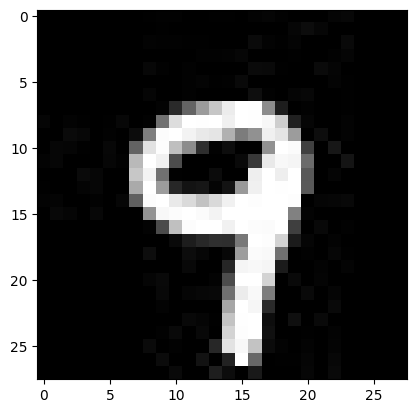

In [22]:
img, one_hot_position = train[55555]

cls = train.classes[one_hot_position]
print(f'Класс: {cls}')
plt.imshow(img, cmap='gray')

In [23]:
train, val = random_split(train, [0.8,0.2])

In [24]:
print(f'Длинна трейна: {len(train)}')
print(f'Длинна валидации: {len(val)}')
print(f'Длинна теста: {len(test)}')

Длинна трейна: 48000
Длинна валидации: 12000
Длинна теста: 10000


In [25]:
train_loader = DataLoader(train, batch_size=16, shuffle=True) # Трейна всегда перемешивать
val_loader = DataLoader(val, batch_size=16, shuffle=False) 
test_loader = DataLoader(test, batch_size=16, shuffle=False) 

In [26]:
for i, (samples, target) in enumerate(train_loader):
    if i<3:
        print(f'Номер батча: {i+1}')
        print(f'Размер батча: {samples.shape}')
        print(f'Размер ответов: {target.shape}')
print('\n ............... \n')
print(f'Номер батча: {i+1}')
print(f'Размер батча: {samples.shape}')
print(f'Размер ответов: {target.shape}')

Номер батча: 1
Размер батча: torch.Size([16, 28, 28])
Размер ответов: torch.Size([16])
Номер батча: 2
Размер батча: torch.Size([16, 28, 28])
Размер ответов: torch.Size([16])
Номер батча: 3
Размер батча: torch.Size([16, 28, 28])
Размер ответов: torch.Size([16])

 ............... 

Номер батча: 3000
Размер батча: torch.Size([16, 28, 28])
Размер ответов: torch.Size([16])


Использование класса Image Folder - для облегчения работы при создаднии датасета для классификации изображений

In [27]:
train = ImageFolder(r'C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training')
test = ImageFolder(r'C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\testing')

In [28]:
train.classes, train.class_to_idx, len(train), len(test)

(['class_0',
  'class_1',
  'class_2',
  'class_3',
  'class_4',
  'class_5',
  'class_6',
  'class_7',
  'class_8',
  'class_9'],
 {'class_0': 0,
  'class_1': 1,
  'class_2': 2,
  'class_3': 3,
  'class_4': 4,
  'class_5': 5,
  'class_6': 6,
  'class_7': 7,
  'class_8': 8,
  'class_9': 9},
 60000,
 10000)

class_9


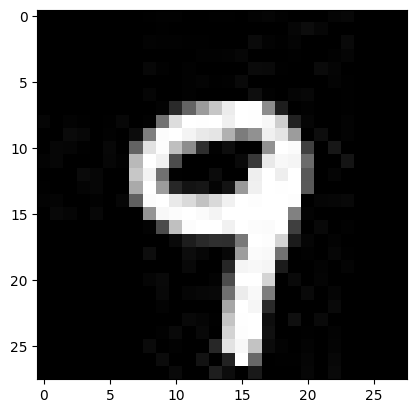

In [29]:
img, one_hot_position = train[55555]
cls = train.classes[one_hot_position]
print(cls)
plt.imshow(img, cmap='gray')

In [30]:
train, val = random_split(train, [0.8,0.2])

In [31]:
train_loader = DataLoader(train, batch_size=16, shuffle=True)
val_loader = DataLoader(val, 16, False)
test_loader = DataLoader(test, 16, False)

Подготовка данных для классификации завершена

### Данные для задачи регрессии

In [32]:
os.listdir(r'C:\Users\arato\Desktop\It_programms\PyTorch\dataset')
len(os.listdir(r'C:\Users\arato\Desktop\It_programms\PyTorch\dataset'))

100001

In [ ]:
class DataReg(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.list_name_file = os.listdir(path)
        if 'coords.json' in self.list_name_file:
            self.list_name_file.remove('coords.json')

        self. len_dataset = len(self.list_name_file)

        with open(os.path.join(self.path, 'coords.json'), 'r') as f:
            self.dict_coords = json.load((f))

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        name_file = self.list_name_file[index]
        path_img = os.path.join(self.path, name_file)

        img = np.array(Image.open(path_img))
        coord = np.array(self.dict_coords[name_file])

        if self.transform is not None:
            img = self.transform(img)

        return img, coord

In [34]:
dataset = DataReg(r'C:\Users\arato\Desktop\It_programms\PyTorch\dataset')

In [35]:
len(dataset)

100000

Координаты: [43 23]


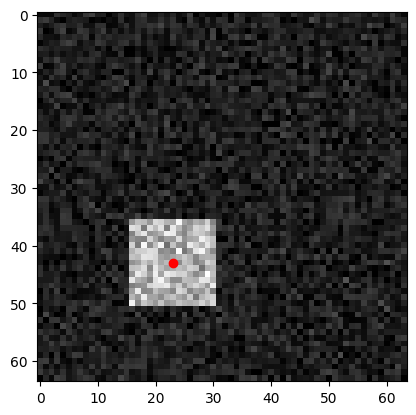

In [36]:
img, coord = dataset[98765]
print(f'Координаты: {coord}')
plt.scatter(coord[1],coord[0], color='red')
plt.imshow(img, 'gray')

С помощью random_split разобъем данные на выборки, а с помощью DataLoader - на батчи

In [37]:
train, val, test = random_split(dataset, [0.7,0.1,0.2])

In [38]:
print(f'Train: {len(train)}')
print(f'Val: {len(val)}')
print(f'Test: {len(test)}')

Train: 70000
Val: 10000
Test: 20000


In [39]:
train_loader = DataLoader(train, 64, True)
val_loader = DataLoader(val, 64, False)
test_loader = DataLoader(test, 64, False)

In [40]:
for i, (samples, target) in enumerate(train_loader):
    if i<3:
        print(f'Номер батча: {i+1}')
        print(f'Размер батча: {samples.shape}')
        print(f'Размер ответов: {target.shape}')
print('\n ............... \n')
print(f'Номер батча: {i+1}')
print(f'Размер батча: {samples.shape}')
print(f'Размер ответов: {target.shape}')

Номер батча: 1
Размер батча: torch.Size([64, 64, 64])
Размер ответов: torch.Size([64, 2])
Номер батча: 2
Размер батча: torch.Size([64, 64, 64])
Размер ответов: torch.Size([64, 2])
Номер батча: 3
Размер батча: torch.Size([64, 64, 64])
Размер ответов: torch.Size([64, 2])

 ............... 

Номер батча: 1094
Размер батча: torch.Size([48, 64, 64])
Размер ответов: torch.Size([48, 2])


### Трасформация изображений

In [41]:
from torchvision import transforms
from torchvision.transforms import v2

V2 отличается от transforms:
* Поддерживает задачи классификации, детекции, сегментации и т.д.
* Поддерживает больше преобразований
* Поддерживает произвольные структуры ввода
* Быстрее

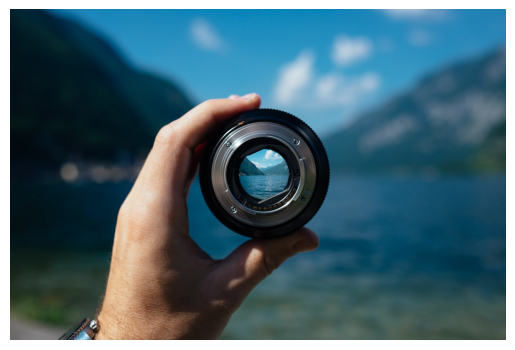

In [42]:
plt.axis('off')
plt.imshow(Image.open(r'photo.jpg'))

In [43]:
img = np.array(Image.open('photo.jpg'))
print(type(img))
print(img.shape)
print(img.dtype)
print(f'min={img.min()}, max={img.max()}')

<class 'numpy.ndarray'>
(1280, 1920, 3)
uint8
min=0, max=255


Преобразуем изображение в тензор.

При работе с pytorch цветовые каналы находятся на 0 оси

In [44]:
transform = transforms.ToTensor()
img_tensor = transform(img)
print(type(img_tensor))
print(img_tensor.shape)
print(img_tensor.dtype)
print(f'min={img_tensor.min()}, max={img_tensor.max()}')

<class 'torch.Tensor'>
torch.Size([3, 1280, 1920])
torch.float32
min=0.0, max=1.0


Нормализация данных

In [45]:
transform = transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
# Особенность: можно передавать только тензоры с типом float
img_norm = transform(img_tensor)

print(type(img_tensor))
print(img_tensor.shape)
print(img_tensor.dtype)
print(f'min={img_norm.min()}, max={img_norm.max()}')

<class 'torch.Tensor'>
torch.Size([3, 1280, 1920])
torch.float32
min=-1.0, max=1.0


Класс Compose создан специально, чтобы последовательно применить трансформации

In [46]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
    ]
)

img = transform(Image.open('photo.jpg'))

print(type(img))
print(img.shape)
print(img.dtype)
print(f'min={img.min()}, max={img.max()}')

<class 'torch.Tensor'>
torch.Size([3, 1280, 1920])
torch.float32
min=-1.0, max=1.0


### Преобразования с V2

In [47]:
transform = v2.ToTensor()
img_v2 = transform((Image.open('photo.jpg')))

c:\Users\arato\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [48]:
transform = v2.ToImage()
img_v2 = transform(Image.open('photo.jpg'))

print(type(img_v2))
print(img_v2.shape)
print(img_v2.dtype)
print(f'min={img_v2.min()}, max={img_v2.max()}')

<class 'torchvision.tv_tensors._image.Image'>
torch.Size([3, 1280, 1920])
torch.uint8
min=0, max=255


Изменение типа данных в V2

In [49]:
transform = v2.ToDtype(torch.float32, scale=True) #Если scale=False, значения будут 0-255
img_dtype_v2 = transform(img_v2)

print(type(img_dtype_v2))
print(img_dtype_v2.shape)
print(img_dtype_v2.dtype)
print(f'min={img_dtype_v2.min()}, max={img_dtype_v2.max()}')

<class 'torchvision.tv_tensors._image.Image'>
torch.Size([3, 1280, 1920])
torch.float32
min=0.0, max=1.0


Нормализируем данные в V2

In [50]:
transform = v2.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
img_norm_v2 = transform(img_dtype_v2)

print(type(img_norm_v2))
print(img_norm_v2.shape)
print(img_norm_v2.dtype)
print(f'min={img_norm_v2.min()}, max={img_norm_v2.max()}')

<class 'torchvision.tv_tensors._image.Image'>
torch.Size([3, 1280, 1920])
torch.float32
min=-1.0, max=1.0


Чтобы оптимально по скорости применять трансформации, нужно соблюдать последовательность:

Преобразование в тензор (Toimage) => Смена типа данных на беззнаковый целочисленный (ToDtype) => Различные преобразования => Смена типа данных на float32 => Нормализация данных (Normalize)

In [51]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
])

img = transform(Image.open('photo.jpg'))

print(type(img))
print(img.shape)
print(img.dtype)
print(f'min={img.min()}, max={img.max()}')

<class 'torchvision.tv_tensors._image.Image'>
torch.Size([3, 1280, 1920])
torch.float32
min=-1.0, max=1.0


### Трансформации для MNIST

In [80]:
class MNISTDataset(Dataset):
    def __init__(self,path,transform=None):
        self.path = path
        self.transform = transform

        self.len_dataset=0 
        self.data_list=[] 
        
        for path_dir, dir_list, file_list in os.walk(path): #путь папки, вложенные папки и файлы
            if path_dir == path:
                self.classes = dir_list
                self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
                continue

            cls = os.path.basename(path_dir) # Имя последней папки/файла из пути

            for name_file in file_list:
                file_path = os.path.join(path_dir, name_file) #объединяет путь к папке и имя файла в один путь к файлу
                self.data_list.append((file_path, self.class_to_idx[cls])) #добавляет пару «путь к файлу и числовой индекс его класса»

            self.len_dataset += len(file_list)

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        file_path, target = self.data_list[index]
        sample = np.array(Image.open(file_path))

        if self.transform is not None:
            sample = self.transform(sample)

        return sample, target

Если вместо модуля transform использовать v2 - результат будет тот же самый

In [96]:
# transform = transforms.Compose(
#     [transforms.ToTensor(),
#      transforms.Normalize(mean=(0.5),std=(0.5))]
# )

transform = v2.Compose(
    [v2.ToImage(),
     v2.Grayscale(),
     v2.ToDtype(torch.float32, scale=True),
     v2.Normalize(mean=(0.5,),std=(0.5,))]
)

In [97]:
train = MNISTDataset(r'C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training', transform=transform)
test = MNISTDataset(r'C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\testing', transform=transform)

In [98]:
img, cls = test[2]
print('img:')
print(type(img))
print(img.shape)
print(img.dtype)
print('cls:')
print(type(cls))
print(cls)

img:
<class 'torchvision.tv_tensors._image.Image'>
torch.Size([1, 28, 28])
torch.float32
cls:
<class 'int'>
0


In [99]:
train, val = random_split(train, [0.8,0.2])

In [100]:
train_loader = DataLoader(train, 16, True)
val_loader = DataLoader(val, 16, False)
test_loader = DataLoader(test, 16, False)

In [101]:
img, cls = next(iter(train_loader))
print('img:')
print(type(img))
print(img.shape)
print(img.dtype)
print('cls:')
print(type(cls))
print(cls.shape)
print(cls.dtype)

img:
<class 'torch.Tensor'>
torch.Size([16, 1, 28, 28])
torch.float32
cls:
<class 'torch.Tensor'>
torch.Size([16])
torch.int64


In [102]:
train = ImageFolder(r'C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\training', transform=transform)
test = ImageFolder(r'C:\Users\arato\Desktop\It_programms\PyTorch\MNIST\testing', transform=transform)

Класс ImageFolder всегда возвращает 3 цветовых канала. Это можно исправить, добавив трансформацию v2.Grayscale() 

In [103]:
img, cls = test[200]
print('img:')
print(type(img))
print(img.shape)
print(img.dtype)
print('cls:')
print(type(cls))
print(cls)

img:
<class 'torchvision.tv_tensors._image.Image'>
torch.Size([1, 28, 28])
torch.float32
cls:
<class 'int'>
0


In [104]:
train, val = random_split(train, [0.8,0.2])

In [105]:
train_loader = DataLoader(train, 16, True)
val_loader = DataLoader(val, 16, False)
test_loader = DataLoader(test, 16, False)

In [106]:
img, cls = next(iter(train_loader))
print('img:')
print(type(img))
print(img.shape)
print(img.dtype)
print('cls:')
print(type(cls))
print(cls.shape)
print(cls.dtype)

img:
<class 'torch.Tensor'>
torch.Size([16, 1, 28, 28])
torch.float32
cls:
<class 'torch.Tensor'>
torch.Size([16])
torch.int64


### Трансформация данных для задачи регрессии

In [108]:
class DataReg(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.list_name_file = os.listdir(path)
        if 'coords.json' in self.list_name_file:
            self.list_name_file.remove('coords.json')

        self. len_dataset = len(self.list_name_file)

        with open(os.path.join(self.path, 'coords.json'), 'r') as f:
            self.dict_coords = json.load((f))

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        name_file = self.list_name_file[index]
        path_img = os.path.join(self.path, name_file)

        img = Image.open(path_img)
        coord = torch.tensor(self.dict_coords[name_file], dtype=torch.float32)

        if self.transform is not None:
            img = self.transform(img)

        return img, coord

In [109]:
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,),std=(0.5,))
    ]
)

In [110]:
dataset = DataReg(r'C:\Users\arato\Desktop\It_programms\PyTorch\dataset', transform=transform)

In [112]:
img, coord = dataset[2]

print('img:')
print(type(img))
print(img.shape)
print(img.dtype)
print(f'min={img.min()}, max={img.max()}')
print('coord:')
print(type(coord))
print(coord.shape)
print(coord.dtype)

img:
<class 'torchvision.tv_tensors._image.Image'>
torch.Size([1, 64, 64])
torch.float32
min=-1.0, max=0.7411766052246094
coord:
<class 'torch.Tensor'>
torch.Size([2])
torch.float32


In [113]:
train, val, test = random_split(dataset, [0.7,0.1,0.2])

In [115]:
train_loader = DataLoader(train, 32, True)
val_loader = DataLoader(val, 32, False)
test_loader = DataLoader(test, 32, False)

In [116]:
img, coord = next(iter(train_loader))
print('img:')
print(type(img))
print(img.shape)
print(img.dtype)
print('coors:')
print(type(coord))
print(coord.shape)
print(coord.dtype)

img:
<class 'torch.Tensor'>
torch.Size([32, 1, 64, 64])
torch.float32
coors:
<class 'torch.Tensor'>
torch.Size([32, 2])
torch.float32


### Создание собственного класса трансформаций

Если в Pytorch нет нужной нам трансформации, ее можно создать самому. Для этого нужно создать класс, наследуемый от torch.nn.Module, где должен быть метод forward, в котором нужно будет написать логику преобразований

Например:

In [119]:
class MyNormalize(torch.nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = mean
        self.std = std

    def forward(self, sample):
        sample = (sample - self.mean) / self.std
        return sample

In [121]:
transform_1 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5), std=(0.5))
])

transform_2 = transforms.Compose([
    transforms.ToTensor(),
    MyNormalize(0.5, 0.5)
])

In [125]:
img = Image.open(r'C:\Users\arato\Desktop\It_programms\PyTorch\dataset\img_0.jpeg')


In [126]:
img1 = transform_1(img)


print('img1:')
print(type(img1))
print(img1.shape)
print(img1.dtype)
print(f'min={img1.min()}, max={img1.max()}')

img1:
<class 'torch.Tensor'>
torch.Size([1, 64, 64])
torch.float32
min=-1.0, max=0.7176470756530762


In [127]:
img2 = transform_2(img)


print('img2:')
print(type(img2))
print(img2.shape)
print(img2.dtype)
print(f'min={img2.min()}, max={img2.max()}')

img2:
<class 'torch.Tensor'>
torch.Size([1, 64, 64])
torch.float32
min=-1.0, max=0.7176470756530762


In [128]:
torch.equal(img1,img2)

True

При сравнении обоих изображений на равенство видно, что они одинаковые. Значит, созданный нами класс делает точно такие же преобразвоания, как и Normalize